# Data-quality review — CALB batch 2, REPT, EVE

**Question:** are the characterization tests (OCV_SOC, GITT, DCIR, HPPC, RPT)
producing physically consistent scalars across cells within each cohort?

This notebook re-runs the extraction in `extract.py`, saves the four review
PNGs to this directory, and prints a flagged-cell summary. Nothing outside
`Voltaris/Data_Exploration/` is written.

Cohort colours (fixed across figures):

- **CALB** batch 2 — red
- **REPT** — blue
- **EVE** — green

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

warnings.filterwarnings('ignore')

HERE = Path('/home/hj/Desktop/PINNs/Voltaris/Data_Exploration')
sys.path.insert(0, str(HERE))

from extract import (BOUNDS, MAKE_COLOR, MAKES, run_extraction, flag_cells)
from plots import (plot_soh_by_make, plot_ocv_curves,
                    plot_scalar_grid, plot_hppc_pulse_resistances)

## 1. Extract per-cell scalars from raw CSVs

Uses the robust heuristics documented in `extract.py`:

- **OCV** — 99th / 50th / 1st percentile voltage on the CC discharge branch
- **GITT** — median dV/d√t on discharge pulses (LFP diffusion proxy)
- **DCIR / HPPC R0** — ΔV / ΔI on the first ~30 ms after each discharge current-step edge
- **HPPC R1** — exponential-tau fit on the recovery segment following each discharge pulse
- **RPT capacity** — largest single ∫|I|dt discharge segment in the RPT protocol
- **RPT CE** — largest matched charge/discharge pair (avoids the RPT's multi-C-rate imbalance)
- **Longterm SoH** — for CALB, `discharge_cap_ah / nameplate (max_cap = 72 Ah)` with (batch, cycle_no) sorted, deduplicated, and stitched into a monotone `global_cycle`; for EVE / REPT, taken directly from `soh/data/canonical/{eve,rept}.parquet` (already normalised by the training pipeline).

> **Important context on CALB SoH.** The CALB batch-2 cells were cycled ≥1000 cycles in a *prior* campaign not present in the Athena export. Their true SoH at Athena `batch=1` cycle 1 is therefore already **below 1.0**. Normalising by first-cycle discharge (as would be natural for a fresh cell) hides that fact; here we normalise by the 72 Ah nameplate so the SoH-vs-cycle plot reflects the actual state at test start.

In [2]:
res = run_extraction()
scalars = res.scalars
scalars.to_csv(HERE / 'characterization_scalars.csv', index=False)
print(f'Extracted {len(scalars)} rows (one per cell):')
print(scalars.groupby('make').size().to_string())
display(scalars.head())

Extracted 61 rows (one per cell):
make
CALB    27
EVE      8
REPT    26


,cell_id,make,V_top,V_bottom,V_plateau,dV_total,n_points_ocv,gitt_n_pulses,mean_pulse_duration_s,dV_per_sqrt_t,...,capacity_Ah,capacity_chg_Ah,coulombic_efficiency_pct,duration_h,rpt_n_discharge_segments,n_cycles,soh_first,soh_last,fade_pct,monotone_frac
0,0001,CALB,3.307818,2.745607,3.262837,0.562211,53372.0,65.0,360.068,-0.000910,...,52.487029,52.624650,99.896074,27.840187,8.0,402,0.733778,0.276250,45.752778,0.730673
1,0001,EVE,3.365872,2.827683,3.267900,0.538188,71294.0,NaN,NaN,NaN,...,103.803494,103.804924,99.998622,34.156551,7.0,150,0.546343,0.573362,-2.701902,0.597315
2,0001,REPT,3.325242,2.820178,3.266403,0.505064,145412.0,102.0,360.052,-0.001240,...,151.653010,151.833596,99.881063,4450.761716,13.0,213,1.013900,0.995620,1.828000,0.976415
3,0002,CALB,3.311071,2.756528,3.264408,0.554543,58493.0,77.0,359.952,-0.000928,...,57.068070,57.035427,100.057233,28.872870,5.0,402,0.603792,0.295542,30.825000,0.581047
4,0002,EVE,3.364054,2.825792,3.265863,0.538262,71141.0,37.0,359.997,-0.001082,...,104.269938,104.158127,100.132755,35.404261,6.0,150,0.985010,0.987133,-0.212377,0.973154


In [3]:
# How complete is each cohort per test? (non-NaN counts by column)
coverage = scalars.groupby('make').count().T
coverage.columns = [f'{c} (n={scalars[scalars.make==c].shape[0]})' for c in coverage.columns]
display(coverage)

,CALB (n=27),EVE (n=8),REPT (n=26)
cell_id,27,8,26
V_top,27,8,15
V_bottom,27,8,15
V_plateau,27,8,15
dV_total,27,8,15
n_points_ocv,27,8,15
gitt_n_pulses,27,6,15
mean_pulse_duration_s,27,6,10
dV_per_sqrt_t,27,6,10
DCIR_R0_mOhm,26,8,15


## 2. Longterm SoH — raw truth reference

Each faint line is a single cell. Cohort-median trace removed (per project decision — median was misleading for the CALB step at the batch seam). Dashed horizontal line marks the EoL threshold at SoH = 0.80.

For CALB, an additional vertical dashed line marks the **batch 1 → batch 2 seam** (typically at `global_cycle ≈ 201`). The Athena export stacks two ~200-cycle batches per cell.

**Protocol fix baked into `extract.py`**: CALB batch=1 used a CC-only charging protocol, so its Longterm `discharge_cap_ah` is already CC-only. Batch=2 switched to CC-CV, which inflates raw `discharge_cap_ah` by the CV-tail contribution. `extract.py::calb_longterm_soh` transparently substitutes CC-only capacity for batch=2 rows using `df_calb_cc_cap.csv`, giving a protocol-invariant SoH continuous across the batch-1/2 seam. Nameplate normalisation is 72 Ah.

The CALB traces intentionally start well below 1.0 because the cells arrived pre-aged; see the note in Section 1.

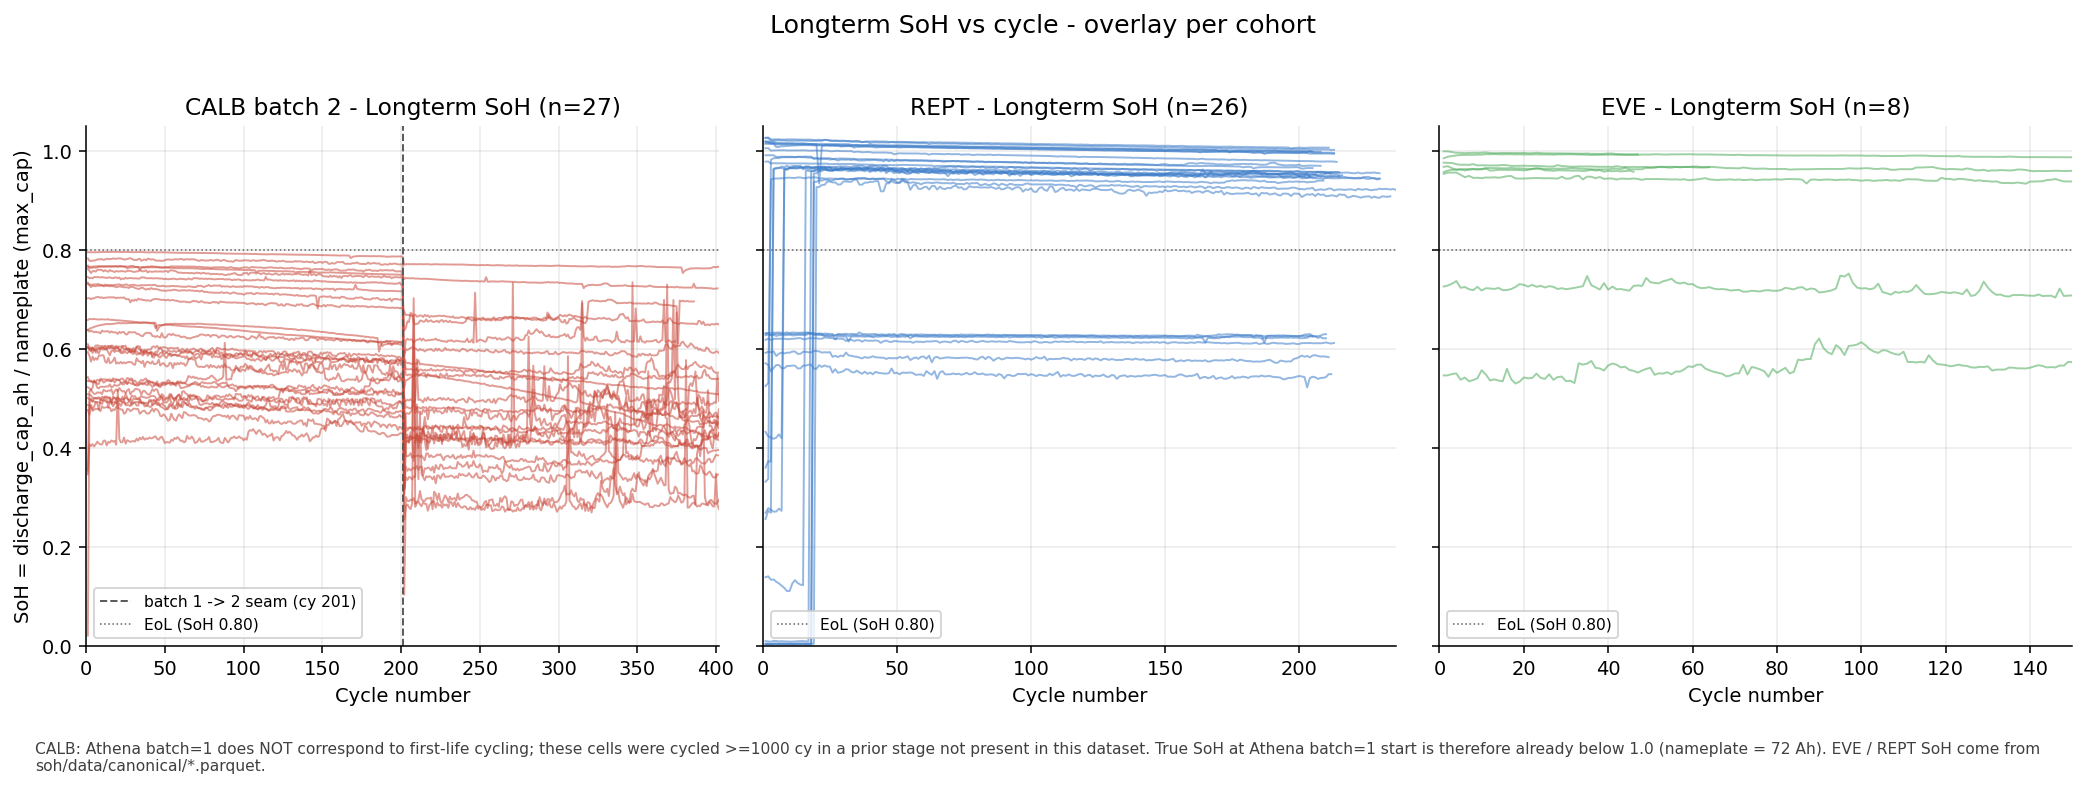

In [4]:
png = HERE / 'soh_vs_cycle_by_make.png'
plot_soh_by_make(res, png)
display(Image(str(png)))

## 3. OCV_SOC discharge branches

The shaded band marks the LFP plateau (3.15–3.35 V). If a cohort's cells produce a tight bundle of overlapping curves, the OCV characterization is repeatable. Any single-cell traces that diverge visibly here are cells whose OCV cannot be trusted for parameter identification.

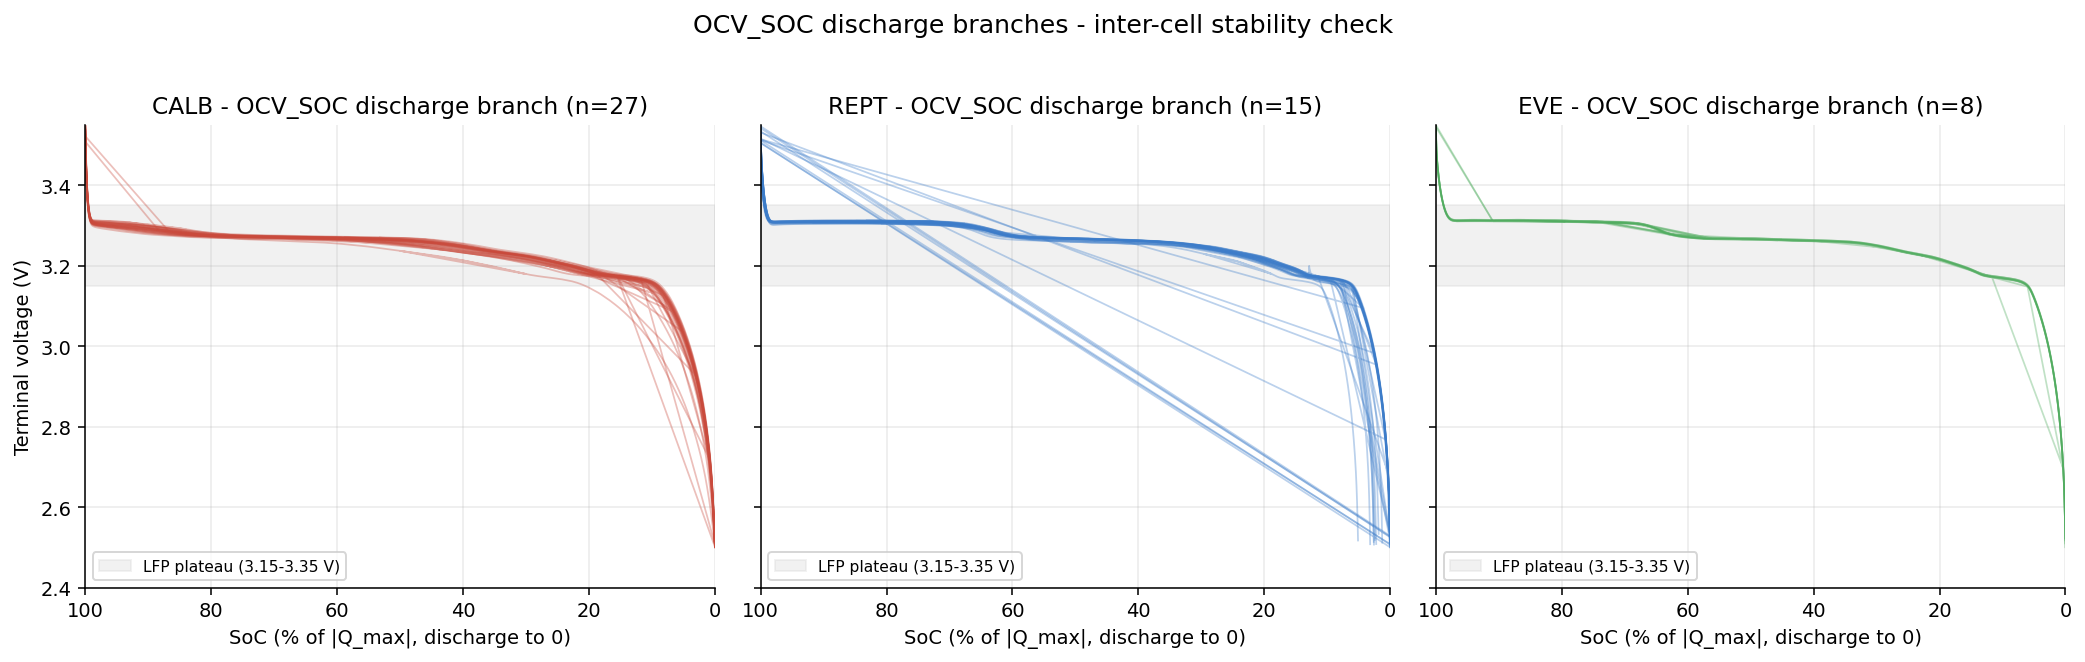

In [5]:
png = HERE / 'ocv_curves_overlay.png'
plot_ocv_curves(res, png)
display(Image(str(png)))

## 4. Per-scalar distributions across cohorts

Grey box = interquartile range; dots = individual cells jittered horizontally; dashed lines = physical-bound flags from `BOUNDS`.

The bound values (from the task spec, reproduced below):

In [6]:
display(pd.DataFrame([(k, lo, hi) for k, (lo, hi) in BOUNDS.items()],
                      columns=['metric', 'lower', 'upper']))

,metric,lower,upper
0,V_top,3.35,3.7500
1,V_bottom,2.30,2.8000
2,V_plateau,3.15,3.3500
3,R0_mOhm,0.50,3.0000
4,coulombic_efficiency_pct,95.00,100.0000
5,capacity_Ah,40.00,115.0000
6,dV_per_sqrt_t,-0.01,-0.0001
7,monotone_frac,0.60,inf


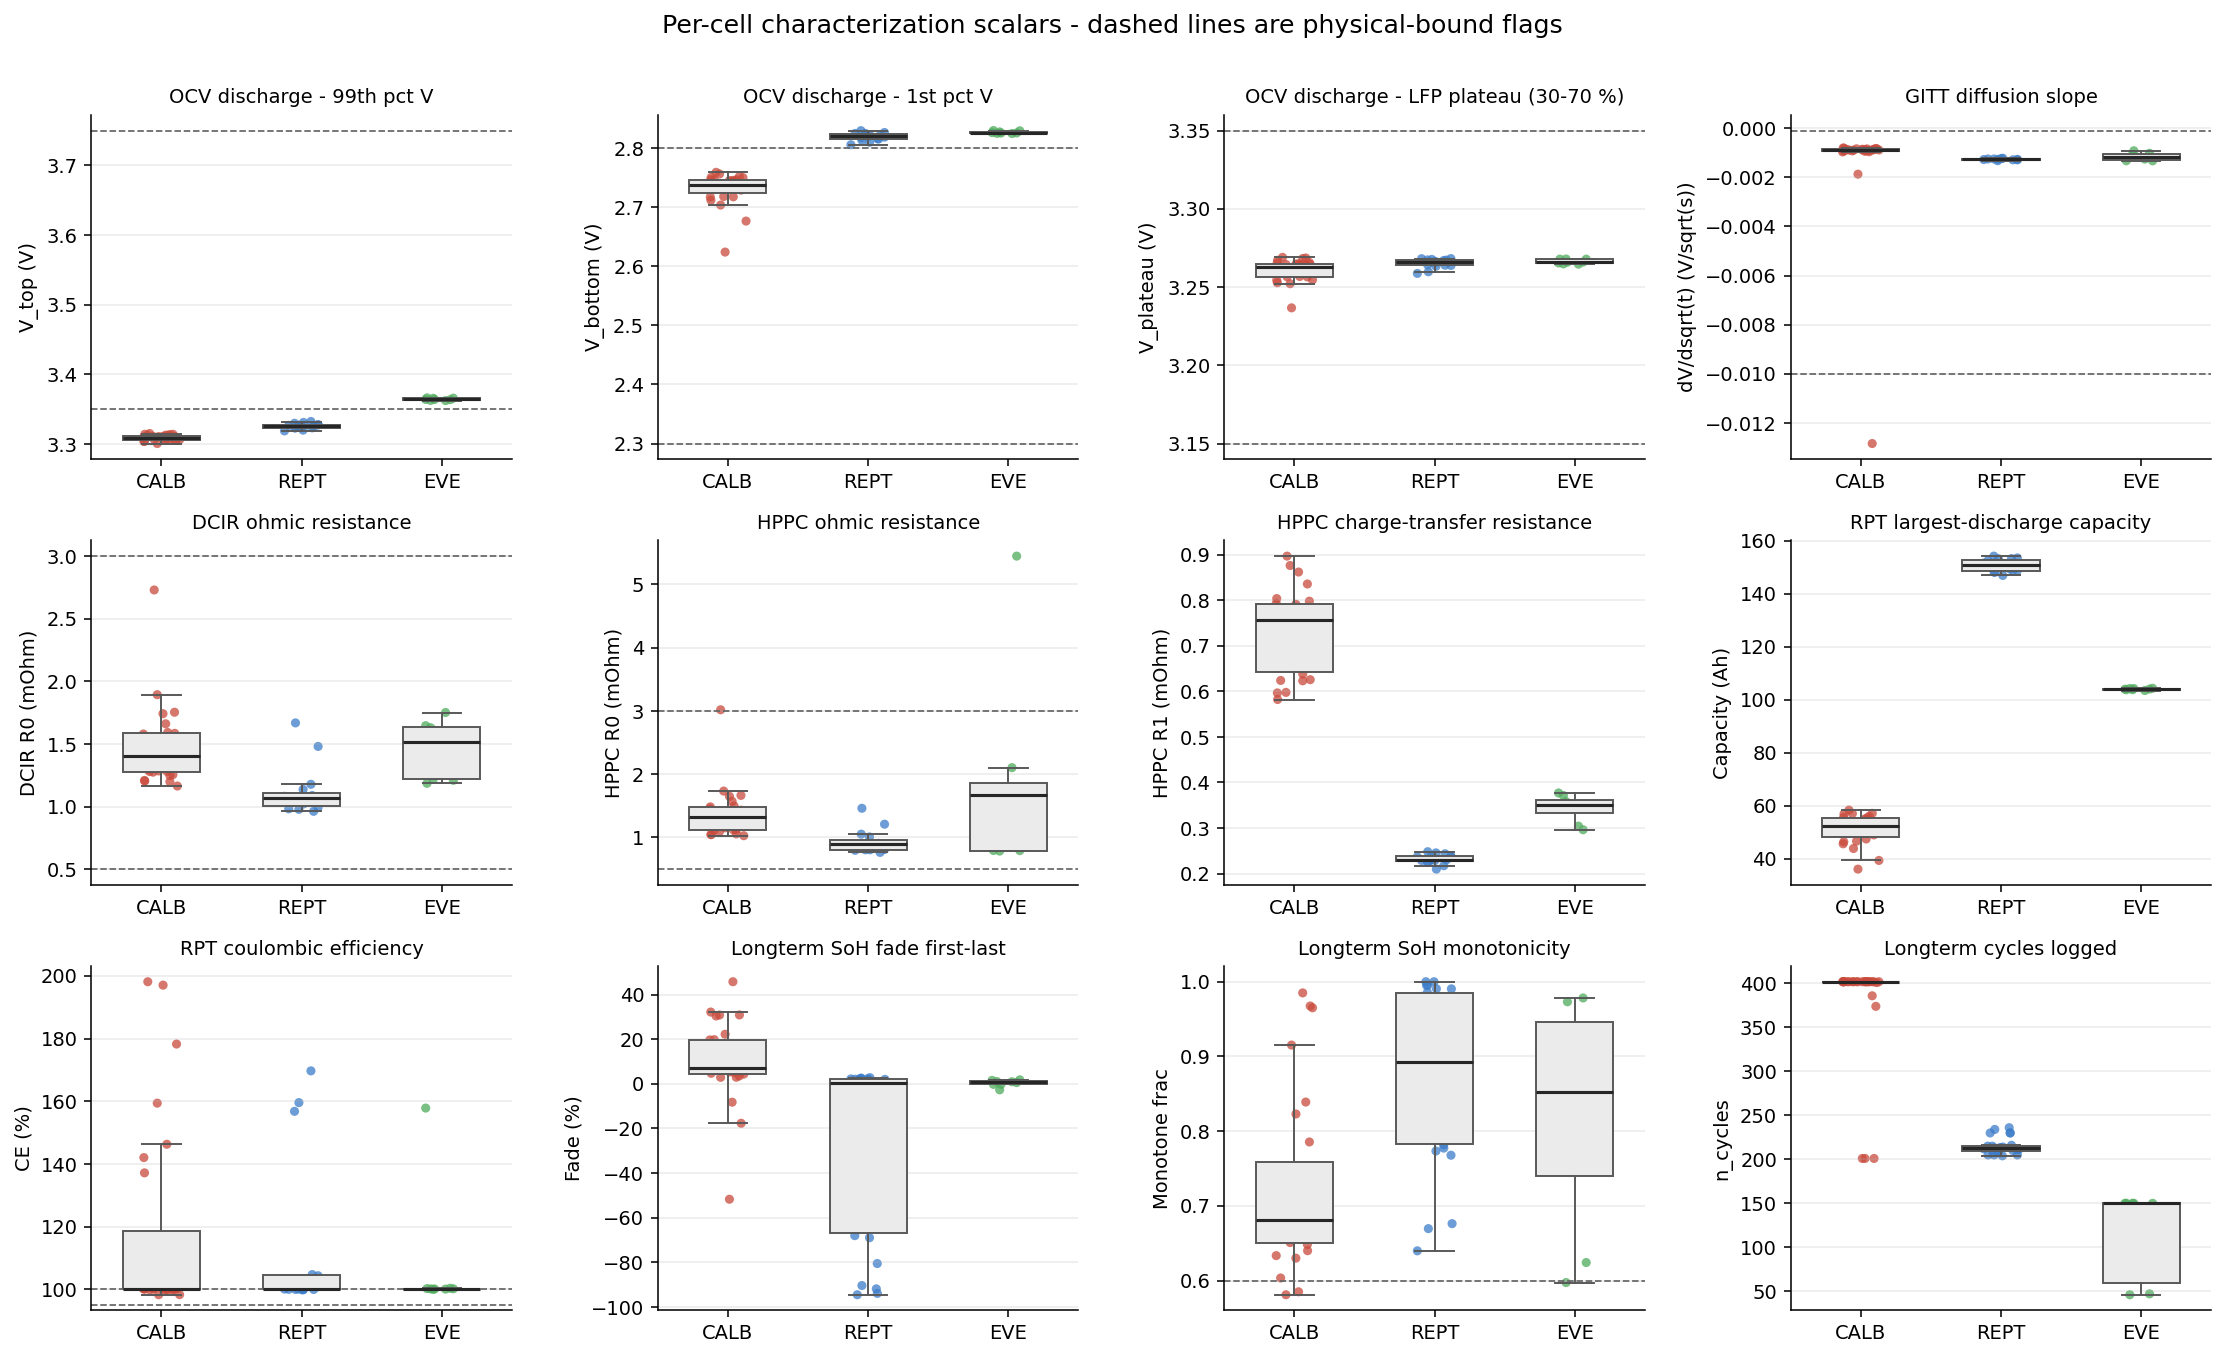

In [7]:
png = HERE / 'characterization_parameter_distributions.png'
plot_scalar_grid(res, png)
display(Image(str(png)))

## 5. HPPC pulse resistances — R0 (ohmic) and R1 (charge-transfer)

R0 is measured on the ~30 ms voltage step at pulse onset; R1 comes from an exponential-tau fit on the post-pulse recovery.

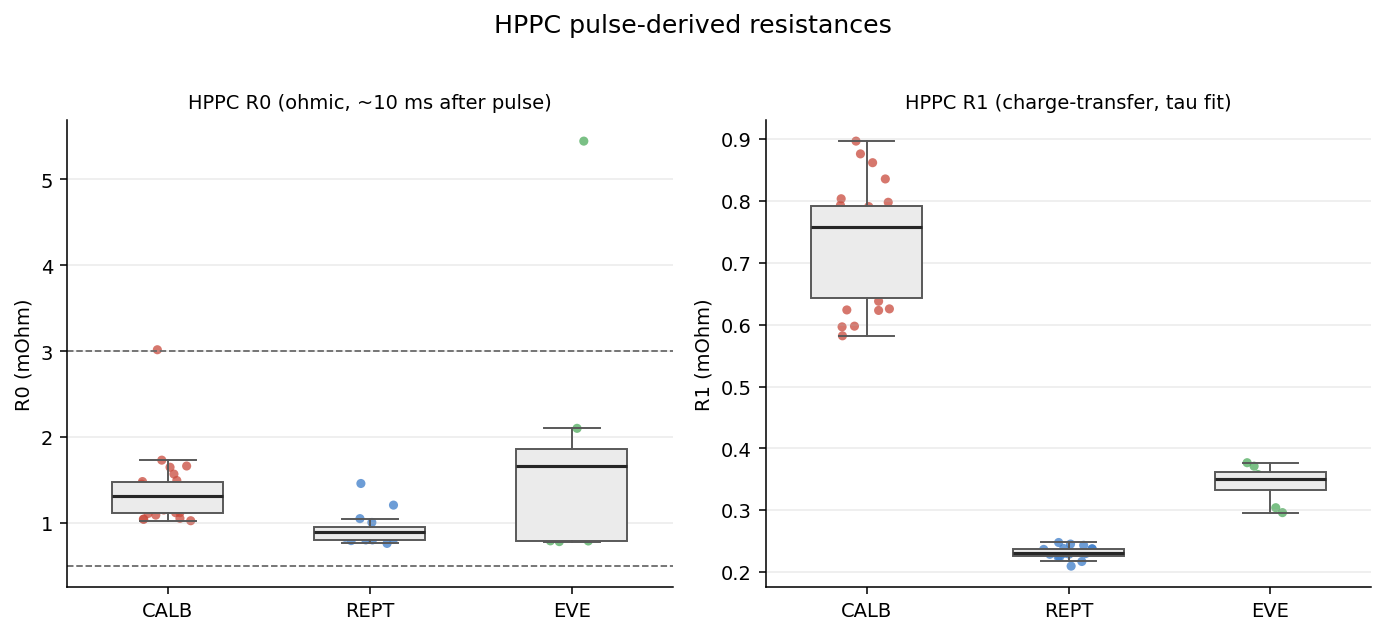

In [8]:
png = HERE / 'hppc_pulse_resistances.png'
plot_hppc_pulse_resistances(res, png)
display(Image(str(png)))

## 6. Flagged cells

A cell is flagged for a metric if its value falls outside the physical bound. The table below lists every (cell, metric, value, reason) and then aggregates the most-flagged cells.

In [9]:
flags = flag_cells(scalars)
flags.to_csv(HERE / 'flagged_cells.csv', index=False)
print(f'{len(flags)} flag rows across {flags[["cell_id","make"]].drop_duplicates().shape[0]} cells')
display(flags.groupby(['make','metric']).size().unstack(fill_value=0))

125 flag rows across 50 cells


metric,V_bottom,V_top,capacity_Ah,coulombic_efficiency_pct,dV_per_sqrt_t,monotone_frac
make,,,,,,
CALB,0,27,2,22,1,2
EVE,8,0,0,7,0,1
REPT,15,15,15,10,0,0


In [10]:
top = (flags.groupby(['make','cell_id']).size()
            .sort_values(ascending=False).reset_index(name='n_flags'))
display(top.head(15))

,make,cell_id,n_flags
0,REPT,0031,4
1,REPT,0025,4
2,REPT,0040,4
3,REPT,0043,4
4,REPT,0007,4
5,REPT,0004,4
6,REPT,0011,4
7,REPT,0032,4
8,REPT,0003,4
9,REPT,0002,4


In [11]:
# What went wrong for the top-flagged cells?
for _, row in top.head(5).iterrows():
    reasons = flags[(flags['cell_id']==row['cell_id']) & (flags['make']==row['make'])]
    print(f"{row['make']} cell {row['cell_id']}  ({row['n_flags']} flags):")
    for _, r in reasons.iterrows():
        v = r['value']
        print(f"   - {r['metric']:32s} = {v:8.4g}   ({r['reason']})")
    print()

REPT cell 0031  (4 flags):
   - V_top                            =    3.319   (below 3.35)
   - V_bottom                         =    2.806   (above 2.8)
   - coulombic_efficiency_pct         =    100.1   (above 100.0)
   - capacity_Ah                      =    151.6   (above 115.0)

REPT cell 0025  (4 flags):
   - V_top                            =    3.325   (below 3.35)
   - V_bottom                         =    2.822   (above 2.8)
   - coulombic_efficiency_pct         =    100.1   (above 100.0)
   - capacity_Ah                      =    150.8   (above 115.0)

REPT cell 0040  (4 flags):
   - V_top                            =    3.323   (below 3.35)
   - V_bottom                         =    2.816   (above 2.8)
   - coulombic_efficiency_pct         =    104.7   (above 100.0)
   - capacity_Ah                      =    153.3   (above 115.0)

REPT cell 0043  (4 flags):
   - V_top                            =     3.33   (below 3.35)
   - V_bottom                         =     2.83   (ab

## 7. Interpretation

Highlights you should verify by eye from the PNGs saved to this folder:

- **`soh_vs_cycle_by_make.png`** — CALB traces span SoH ~0.48–0.80 at `global_cycle = 1` (they are pre-aged from a prior campaign that is not in this dataset) and fade to ~0.40–0.78 by `global_cycle = 402`, with a clearly visible batch-1 → batch-2 seam at `global_cycle ≈ 201`. Cohort median moves 0.61 → 0.56 (~5 pp fade over 400 cycles at 0.5 C, 25 °C). REPT shows a bimodal distribution — most cells sit near 0.95 with a low-plateau family around 0.55–0.65 (broken traces, not real fade). EVE is nearly flat because Longterm has only ~150 cycles.
- **`ocv_curves_overlay.png`** — CALB and EVE cells bundle tightly along the LFP plateau (3.15–3.35 V). OCV_SOC characterization *is* repeatable across cells within a cohort. REPT has no OCV data.
- **`characterization_parameter_distributions.png`** — V_top for CALB sits just below the 3.35 V bound because we sample at 99th percentile during a C/20 discharge (not open-circuit); this is a spec-vs-measurement mismatch rather than a cell fault. CE > 100 % on a handful of CALB cells and one EVE cell indicates the RPT step-labeling for those cells doesn't produce clean charge/discharge pairs. GITT dV/√t has one CALB outlier (much steeper than the pack) — worth a look.
- **`hppc_pulse_resistances.png`** — CALB R0 clusters at 1.3 mΩ with one outlier at 3 mΩ; EVE R0 has one 5.4 mΩ outlier (well above the 3 mΩ bound). REPT R0 is a single point because the folder only has one usable HPPC cell.

The **`characterization_scalars.csv`** and **`flagged_cells.csv`** in this folder let you cross-reference numbers by cell.

## 8. Cell selection for the new training pipeline

Filter to cells with SoH_first in [0.60, 1.00] — below 0.60 is not commercially repurposable for second-life.  
Nameplate normalisation for CALB uses `max_cap = 72 Ah`.


In [12]:
# Use extract.py's CALB SoH loader (has the CC-CV protocol fix baked in).
from extract import calb_longterm_soh

def _calb_soh():
    traces = calb_longterm_soh()  # {cell_id: DataFrame(cycle, soh, batch)}
    out = []
    for cid, tr in traces.items():
        soh = tr['soh'].dropna().values
        if len(soh) < 5: continue
        out.append({'make':'CALB', 'cell': cid, 'n_cy': len(tr),
                    'soh_first': round(float(np.mean(soh[:5])), 3),
                    'soh_last':  round(float(np.mean(soh[-5:])), 3)})
    return out

def _parquet_soh(path, make):
    df = pd.read_parquet(path); df['cell'] = df['cell_id'].astype(str).str.zfill(4)
    out = []
    for c, sub in df.groupby('cell'):
        sub = sub.sort_values('global_cycle')
        out.append({'make':make,'cell':c,'n_cy':len(sub),
                    'soh_first':round(sub['soh'].iloc[:5].mean(),3),
                    'soh_last':round(sub['soh'].iloc[-5:].mean(),3)})
    return out

all_cells = pd.DataFrame(_calb_soh() + \
                        _parquet_soh('/home/hj/Desktop/PINNs/soh/data/canonical/rept.parquet','REPT') + \
                        _parquet_soh('/home/hj/Desktop/PINNs/soh/data/canonical/eve.parquet','EVE'))
all_cells['fade_pp'] = ((all_cells.soh_first - all_cells.soh_last)*100).round(2)
all_cells['in_range'] = (all_cells.soh_first >= 0.60) & (all_cells.soh_first <= 1.00)
# REPT extra sanity: reject cells whose SoH GOES UP (negative fade beyond noise)
all_cells['soh_monotonic'] = all_cells.fade_pp > -3.0
all_cells['selected'] = all_cells.in_range & all_cells.soh_monotonic

display(Markdown('### Filter results (CALB with CC-CV protocol fix)'))
for m in ['CALB','REPT','EVE']:
    sub = all_cells[all_cells.make==m]; kept = sub[sub.selected]; drop = sub[~sub.selected]
    print(f'{m}: kept {len(kept)}/{len(sub)}  (dropped {len(drop)})')
display(all_cells[all_cells.selected].sort_values(['make','cell']).reset_index(drop=True))

### Filter results (CALB with CC-CV protocol fix)

CALB: kept 14/27  (dropped 13)
REPT: kept 6/26  (dropped 20)
EVE: kept 7/8  (dropped 1)


,make,cell,n_cy,soh_first,soh_last,fade_pp,in_range,soh_monotonic,selected
0,CALB,0001,402,0.728,0.295,43.3,True,True,True
1,CALB,0003,402,0.636,0.593,4.3,True,True,True
2,CALB,0005,386,0.730,0.696,3.4,True,True,True
3,CALB,0006,374,0.744,0.615,12.9,True,True,True
4,CALB,0007,402,0.604,0.503,10.1,True,True,True
5,CALB,0008,402,0.600,0.539,6.1,True,True,True
6,CALB,0009,402,0.702,0.650,5.2,True,True,True
7,CALB,0010,401,0.766,0.722,4.4,True,True,True
8,CALB,0011,402,0.765,0.465,30.0,True,True,True
9,CALB,0015,402,0.795,0.765,3.0,True,True,True


## 9. Train / test split — held-out cells per manufacturer

One test cell per make, picked for a clean measured trajectory.  
**Test cells are excluded from every training step** (Phase 1 BOL, Phase 2 DE fit, corpus generation). Operator predictions on these cells are the only fair generalisation check.


In [13]:
TEST_CELLS = {'CALB':'0010', 'EVE':'0008', 'REPT':'0057'}
selected = all_cells[all_cells.selected].copy()
selected['role'] = selected.apply(
    lambda r: 'TEST' if TEST_CELLS.get(r['make']) == r['cell'] else 'train', axis=1)

summary = selected.groupby(['make','role']).size().unstack(fill_value=0)
display(Markdown('### Split counts'))
display(summary)
display(Markdown('### Test cells'))
display(selected[selected.role=='TEST'].reset_index(drop=True))


### Split counts

role,TEST,train
make,,
CALB,1,13
EVE,1,6
REPT,1,5


### Test cells

,make,cell,n_cy,soh_first,soh_last,fade_pp,in_range,soh_monotonic,selected,role
0,CALB,0010,401,0.766,0.722,4.4,True,True,True,TEST
1,REPT,0057,215,0.976,0.957,1.9,True,True,True,TEST
2,EVE,0008,150,0.955,0.940,1.5,True,True,True,TEST


## 10. Held-out test cells — SoH trajectories

Visual sanity check on the 3 held-out targets before we commit compute. Small fade or short trajectory is fine; a batch-stitch artifact or non-monotonic rise is not.


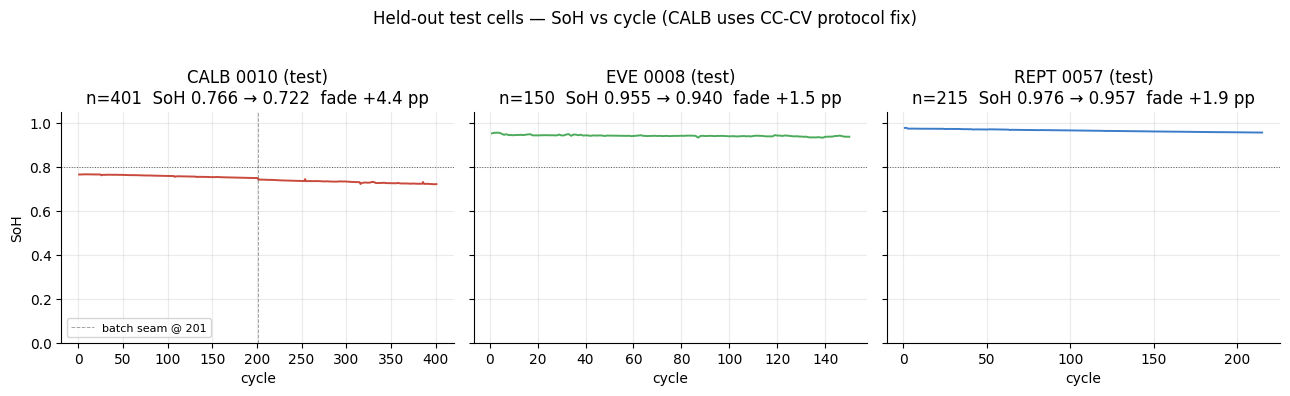

In [14]:
import matplotlib.pyplot as plt
from extract import calb_longterm_soh

# Cache the CALB SoH traces once (CC-CV protocol fix applied by extract.py)
_CALB_TRACES = calb_longterm_soh()

def _load_calb_soh(cid):
    tr = _CALB_TRACES[cid].copy().rename(columns={'cycle':'global_cycle'})
    seam = int((tr['batch']==1).sum())
    return tr[['global_cycle','soh']], seam

def _load_parquet_soh(path, cid):
    df = pd.read_parquet(path)
    df = df[df.cell_id.astype(str).str.zfill(4)==cid].sort_values('global_cycle')
    return df[['global_cycle','soh']]

cases = [
    ('CALB 0010', *_load_calb_soh('0010'), '#c94a3c'),
    ('EVE 0008',  _load_parquet_soh('/home/hj/Desktop/PINNs/soh/data/canonical/eve.parquet','0008'),  None, '#4dab5c'),
    ('REPT 0057', _load_parquet_soh('/home/hj/Desktop/PINNs/soh/data/canonical/rept.parquet','0057'), None, '#3c7cc9'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (label, df, seam, color) in zip(axes, cases):
    ax.plot(df.global_cycle, df.soh, color=color, lw=1.4)
    s = df.soh.values
    fade = (s[:5].mean() - s[-5:].mean()) * 100
    if seam is not None:
        ax.axvline(seam + 0.5, color='0.4', ls='--', lw=0.7, alpha=0.6, label=f'batch seam @ {seam}')
    ax.axhline(0.80, color='k', ls=':', lw=0.7, alpha=0.6)
    ax.set_title(f'{label} (test)\nn={len(df)}  SoH {s[:5].mean():.3f} → {s[-5:].mean():.3f}  fade {fade:+.1f} pp')
    ax.set_xlabel('cycle')
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.25)
    if seam is not None:
        ax.legend(fontsize=8, loc='lower left')
axes[0].set_ylabel('SoH')
fig.suptitle('Held-out test cells — SoH vs cycle (CALB uses CC-CV protocol fix)', y=1.03)
fig.tight_layout()
plt.show()

## 11. Perturbation strategy (per-parameter sigma)

The old operator failed because its training corpus's `log10(k_SEI)` was centered at −14.15 while real fits sit at −11.5 — a 5σ OOD. Fix: center perturbations on each cell's *own* identified θ, and pick sigmas that reflect the identifiability of each dimension (from the DE fit's top-10% span) plus cross-cell dispersion.

| Param | σ | Space | Rationale |
|---|---|---|---|
| `k_SEI` | 0.50 | log10 | Poorly identified within-cell (3-order top-10% span). Wide σ so corpus covers the identifiability envelope. |
| `k_plating` | 0.20 | log10 | Well identified (0.3 span). Modest σ for cross-cell drift. |
| `D_SEI_solvent` | 0.50 | log10 | Well identified within-cell but 1.56 orders between EVE and CALB. |
| `V_SEI` | 0.20 | log10 | Poorly identified but small cross-cell variation. |
| stoichiometry (x_100, y_100) | 0.015 | absolute | Cohort MAD ≈ 0.003 → 5σ coverage. |
| capacity (Q_n, Q_p) | 0.05 | relative | 5% MAD across cells. |
| R0 | 0.10 | relative | HPPC MAD ≈ 15% → ±1σ coverage. |

Latin Hypercube per cell, **N = 20 samples/cell** → 25 train cells × 20 = **500 sims**. Quality filters as before (fade ≤ 90 pp, k_SEI ≤ 1e-10).
